<a href="https://colab.research.google.com/github/WithoutAnyTime/DataExploration/blob/main/zad_klasteryzacja.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

## Zadanie 1
    
Wczytaj dane z pliku **PersonalData.csv**.
    
Oblicz odległość euklidesową \(d(A, B)\) między dwoma wybranymi rekordami \(A\) i \(B\).
    
Zmodyfikuj skalę dla atrybutu **zarobki** (przeskaluj jednostki z tysięcy na złote) i ponownie oblicz odległość euklidesową. Jak zmiana skali wpływa na wynik?
    
Aby wyeliminować wpływ skali, podziel wartość każdego atrybutu przez jego odchylenie standardowe. Oblicz ponownie odległość euklidesową dla przeskalowanych danych.
    
Dla punktów \(A\) i \(B\) oblicz także odległość Minkowskiego oraz odległość miejską (Manhattan).

In [7]:
from scipy.spatial import distance

df = pd.read_csv("PersonalData.csv", index_col=0, delimiter=",")

record_A = df.loc['A']
record_B = df.loc['B']


numerical_df = df.select_dtypes(include=np.number)
record_A_num = numerical_df.loc['A']
record_B_num = numerical_df.loc['B']

print(f"Odległość euklidesowa między A i B (oryginalne dane): {distance.euclidean(record_A_num, record_B_num)}")


df_scaled_zarobki = numerical_df.copy()
df_scaled_zarobki['Zarobki (tys.)'] = df_scaled_zarobki['Zarobki (tys.)'] * 1000

record_A_scaled_zarobki = df_scaled_zarobki.loc['A']
record_B_scaled_zarobki = df_scaled_zarobki.loc['B']

print(f"Odległość euklidesowa po przeskalowaniu 'zarobków' na złote: {distance.euclidean(record_A_scaled_zarobki, record_B_scaled_zarobki)}")
print("Zmiana skali dla atrybutu 'zarobki' zwiększa jego wpływ na odległość euklidesową, co skutkuje większą wartością odległości, ponieważ różnica w 'zarobkach' jest teraz znacznie większa.")


df_standardized = numerical_df.copy()
for col in df_standardized.columns:
    std_dev = df_standardized[col].std()
    if std_dev != 0:
        df_standardized[col] = df_standardized[col] / std_dev

record_A_standardized = df_standardized.loc['A']
record_B_standardized = df_standardized.loc['B']

print(f"Odległość euklidesowa po przeskalowaniu przez odchylenie standardowe: {distance.euclidean(record_A_standardized, record_B_standardized)}")
print(f"Odległość Minkowskiego (p=3) między A i B: {distance.minkowski(record_A_num, record_B_num, p=3)}")
print(f"Odległość miejska (Manhattan) między A i B: {distance.cityblock(record_A_num, record_B_num)}")

Odległość euklidesowa między A i B (oryginalne dane): 30.604574821421714
Odległość euklidesowa po przeskalowaniu 'zarobków' na złote: 800.5847862656397
Zmiana skali dla atrybutu 'zarobki' zwiększa jego wpływ na odległość euklidesową, co skutkuje większą wartością odległości, ponieważ różnica w 'zarobkach' jest teraz znacznie większa.
Odległość euklidesowa po przeskalowaniu przez odchylenie standardowe: 4.0
Odległość Minkowskiego (p=3) między A i B: 24.524624416199366
Odległość miejska (Manhattan) między A i B: 68.8


## Zadanie 2

Napisz program pozwalający obliczać podobieństwo między sekwencjami DNA traktowanymi jako ciągi znaków.

Zaimplementować na podstawie metryki
$$
D(x, y) = |x| + |y| - 2|LCS(x,y)|
$$

gdzie LCS oznacza najdłuszą wspólna podsekwencję (ang.
longest common subsequence)
  
  (LCS(x,y) = bcde). D(x, y) = 3

In [8]:
def lcs_length(X, Y):
    m = len(X)
    n = len(Y)

    dp = [[0] * (n + 1) for _ in range(m + 1)]

    for i in range(m + 1):
        for j in range(n + 1):
            if i == 0 or j == 0:
                dp[i][j] = 0
            elif X[i-1] == Y[j-1]:
                dp[i][j] = dp[i-1][j-1] + 1
            else:
                dp[i][j] = max(dp[i-1][j], dp[i][j-1])
    return dp[m][n]

def get_D_x_y(x, y):
    return len(x) + len(y) - 2 * lcs_length(x, y)

x = "abcde"
y = "bcdxye"
print(get_D_x_y(x, y)) # Oczekiwany wynik 3

X = "AGGTAB"
Y = "GXTXAYB"
print(get_D_x_y(X, Y)) # Oczekiwany wynik 5

3
5


## Zadanie 3

Masz opisy trzech filmów
- `film1 = "kosmiczna stacja astronauta planeta obca"`
- `film2 = "astronauta rakieta księżyc misja kosmiczna"`
- `film3 = "wampir zamek noc krew mroczny"`

a. Stwórz reprezentację wektorową dla każdego filmu używając CountVectorizer

b. Oblicz podobieństwo cosinusowe między wszystkimi parami filmów

c. Które dwa filmy są najbardziej podobne? Które najmniej?

d . Dodaj czwarty film i sprawdź do którego jest najbardziej podobny:
    `film4 = "rakieta mars astronauta czerwona planeta"`

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

film1 = "kosmiczna stacja astronauta planeta obca"
film2 = "astronauta rakieta księżyc misja kosmiczna"
film3 = "wampir zamek noc krew mroczny"

films = [film1, film2, film3]
film_titles = ['film1', 'film2', 'film3']

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(films)

df_vectorized = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out(), index=film_titles)
print("a. Reprezentacja wektorowa filmów:")
print(df_vectorized)
print("\n")

cosine_sim_matrix = cosine_similarity(X)
cosine_sim_df = pd.DataFrame(cosine_sim_matrix, index=film_titles, columns=film_titles)

print("b. Macierz podobieństwa cosinusowego:")
print(cosine_sim_df)
print("\n")

max_similarity = -1
min_similarity = 2
most_similar_pair = (None, None)
least_similar_pair = (None, None)

for i in range(len(film_titles)):
    for j in range(i + 1, len(film_titles)):
        similarity = cosine_sim_df.iloc[i, j]
        if similarity > max_similarity:
            max_similarity = similarity
            most_similar_pair = (film_titles[i], film_titles[j])
        if similarity < min_similarity:
            min_similarity = similarity
            least_similar_pair = (film_titles[i], film_titles[j])

print(f"c. Filmy najbardziej podobne: {most_similar_pair} z podobieństwem {max_similarity:.4f}")
print(f"Filmy najmniej podobne: {least_similar_pair} z podobieństwem {min_similarity:.4f}")
print("\n")

film4 = "rakieta mars astronauta czerwona planeta"

all_films = films + [film4]
all_film_titles = film_titles + ['film4']

X_all = vectorizer.fit_transform(all_films)
cosine_sim_matrix_all = cosine_similarity(X_all)
cosine_sim_df_all = pd.DataFrame(cosine_sim_matrix_all, index=all_film_titles, columns=all_film_titles)

print("d. Macierz podobieństwa cosinusowego z filmem 4:")
print(cosine_sim_df_all)
print("\n")

similarities_to_film4 = cosine_sim_df_all['film4'][:-1]
most_similar_to_film4 = similarities_to_film4.idxmax()
max_sim_to_film4 = similarities_to_film4.max()

print(f"Film 'film4' jest najbardziej podobny do '{most_similar_to_film4}' z podobieństwem {max_sim_to_film4:.4f}")

a. Reprezentacja wektorowa filmów:
       astronauta  kosmiczna  krew  księżyc  misja  mroczny  noc  obca  \
film1           1          1     0        0      0        0    0     1   
film2           1          1     0        1      1        0    0     0   
film3           0          0     1        0      0        1    1     0   

       planeta  rakieta  stacja  wampir  zamek  
film1        1        0       1       0      0  
film2        0        1       0       0      0  
film3        0        0       0       1      1  


b. Macierz podobieństwa cosinusowego:
       film1  film2  film3
film1    1.0    0.4    0.0
film2    0.4    1.0    0.0
film3    0.0    0.0    1.0


c. Filmy najbardziej podobne: ('film1', 'film2') z podobieństwem 0.4000
Filmy najmniej podobne: ('film1', 'film3') z podobieństwem 0.0000


d. Macierz podobieństwa cosinusowego z filmem 4:
       film1  film2  film3  film4
film1    1.0    0.4    0.0    0.4
film2    0.4    1.0    0.0    0.4
film3    0.0    0.0    1.0    0

## Zadanie 4

A. Wczytaj dane z pliku **k_means_data.csv.**

B. Zastosuj **algorytm hierarchiczny aglomeracyjny** i wyszukaj w zbiorze danych klastry.

C. Zastosuj **algorytm k-średnich** i wyszukaj w zbiorze danych klastry.

In [10]:
k_df = pd.read_csv("k_means_data.csv", delimiter=",")

if '# X1' in k_df.columns:
    k_df = k_df.rename(columns={'# X1': 'X1'})


cluster = AgglomerativeClustering(n_clusters=3, linkage='ward', metric='euclidean')
agglomerative_labels = cluster.fit_predict(k_df)
print("Agglomerative Clustering Labels:")
print(agglomerative_labels)


kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans_labels = kmeans.fit_predict(k_df)
print("\nK-Means Clustering Labels:")
print(kmeans_labels)

Agglomerative Clustering Labels:
[1 1 0 1 1 2 1 2 2 1 2 2 1 2 1 2 1 1 2 1 2 0 0 1 0 0 2 1 0 0 1 0 0 0 1 1 1
 0 2 1 0 0 2 1 2 0 1 0 1 0 0 2 2 0 2 1 2 0 0 0 1 0 0 1 2 0 1 2 2 2 0 2 0 1
 2 0 1 2 2 0]

K-Means Clustering Labels:
[0 0 1 0 0 2 0 2 2 0 2 2 0 2 0 2 0 0 2 0 2 1 1 0 1 1 2 0 1 1 0 1 1 1 0 0 0
 1 2 0 1 1 2 0 2 1 0 1 0 1 1 2 2 1 2 0 2 1 1 1 0 1 1 0 2 1 0 2 2 2 1 2 1 0
 2 1 0 2 2 1]


## Zadanie 5

Zaimplementuj samodzielnie **algorytm k-średnich** dla danych z pliku **k_means_data.csv**.

In [11]:
import numpy as np
import pandas as pd

def initialize_centroids(data, k):
    indices = np.random.choice(data.shape[0], k, replace=False)
    return data[indices]

def assign_to_clusters(data, centroids):
    distances = np.sqrt(((data - centroids[:, np.newaxis])**2).sum(axis=2))
    return np.argmin(distances, axis=0)

def update_centroids(data, assignments, k):
    new_centroids = np.array([data[assignments == i].mean(axis=0) for i in range(k)])
    return new_centroids

def kmeans_manual(data, k, max_iterations=100, tolerance=1e-4):
    centroids = initialize_centroids(data, k)
    for _ in range(max_iterations):
        assignments = assign_to_clusters(data, centroids)
        new_centroids = update_centroids(data, assignments, k)
        if np.all(np.abs(new_centroids - centroids) < tolerance):
            break
        centroids = new_centroids
    return assignments, centroids


k_df = pd.read_csv("k_means_data.csv", delimiter=",")

if '# X1' in k_df.columns:
    k_df = k_df.rename(columns={'# X1': 'X1'})

data_for_kmeans = k_df.values
k_manual_labels, k_manual_centroids = kmeans_manual(data_for_kmeans, k=3)

print("Manual K-Means Clustering Labels:")
print(k_manual_labels)
print("\nFinal Centroids:")
print(k_manual_centroids)

Manual K-Means Clustering Labels:
[0 0 1 0 2 1 0 1 1 2 1 1 2 1 2 1 2 2 1 0 1 1 2 0 1 1 1 2 1 1 0 1 1 1 2 2 0
 1 1 0 1 1 1 2 1 1 0 1 0 1 1 1 1 1 1 0 1 1 1 1 0 1 1 2 1 1 0 1 1 1 1 1 1 0
 1 1 2 1 1 1]

Final Centroids:
[[ 2.21452548  0.60756938]
 [-0.35552888  3.72714403]
 [ 1.91143595  1.7991213 ]]


## Zadanie 6

1. Załaduj zbiór danych **iris**.
Opis zbioru: https://scikit-learn.org/stable/auto_examples/datasets/plot_iris_dataset.html
2. Narysuj wykres rozrzutu dla współrzędnych **sepal_length** i **sepal_width**. Oznacz różnymi
kolorami i marklami różne klasy kwiatów.
3. Znajdź wartości **minimalne, maksymalne** oraz **średnie odchylenie kwadratowe** dla atrybutów zbioru.
4. Policz **współczynniki korelacji** między atrybutami.
5. Zastosuj **algorytm k-średnich** i znajdź podział na klastry dla współrzędnych **sepal_length** i **sepal_width**.
6. Zastosuj **algorytm hierarchiczny aglomeracyjny** i znajdź podział na klastry dla współrzędnych **sepal_length** i **sepal_width**.

In [12]:
# Wczytanie zbioru danych Iris
iris = datasets.load_iris()

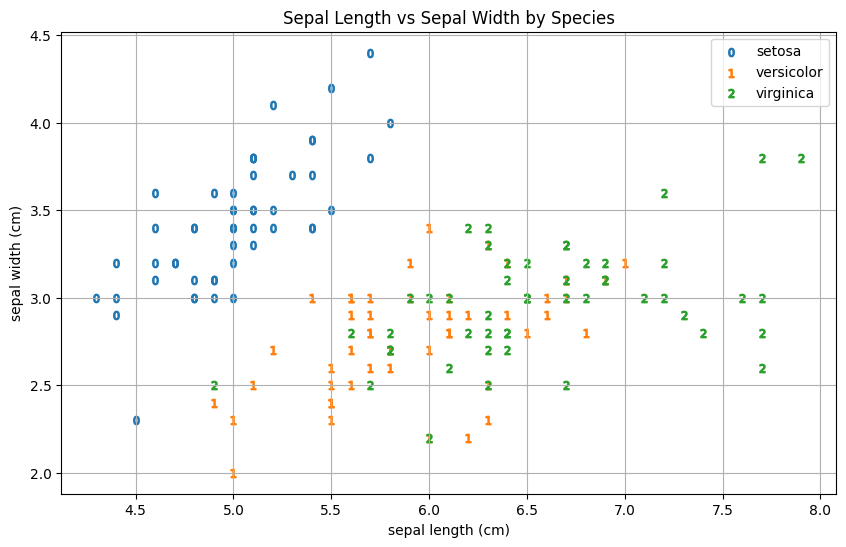


Statystyki dla atrybutów:
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
min           4.300000          2.000000           1.000000          0.100000
max           7.900000          4.400000           6.900000          2.500000
std           0.828066          0.435866           1.765298          0.762238

Współczynniki korelacji między atrybutami:
                   sepal length (cm)  sepal width (cm)  petal length (cm)  \
sepal length (cm)           1.000000         -0.117570           0.871754   
sepal width (cm)           -0.117570          1.000000          -0.428440   
petal length (cm)           0.871754         -0.428440           1.000000   
petal width (cm)            0.817941         -0.366126           0.962865   

                   petal width (cm)  
sepal length (cm)          0.817941  
sepal width (cm)          -0.366126  
petal length (cm)          0.962865  
petal width (cm)           1.000000  

K-Means Clustering Labels (sepal_length,

In [13]:
import matplotlib.pyplot as plt
from sklearn import datasets

iris_df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
iris_df['target'] = iris.target
iris_df['target_names'] = iris.target_names[iris.target]

plt.figure(figsize=(10, 6))
for i, species in enumerate(iris.target_names):
    plt.scatter(iris_df[iris_df['target'] == i]['sepal length (cm)'],
                iris_df[iris_df['target'] == i]['sepal width (cm)'],
                label=species,
                marker=f'${i}$'
               )
plt.xlabel('sepal length (cm)')
plt.ylabel('sepal width (cm)')
plt.title('Sepal Length vs Sepal Width by Species')
plt.legend()
plt.grid(True)
plt.show()

print("\nStatystyki dla atrybutów:")
print(iris_df.drop(columns=['target', 'target_names']).agg(['min', 'max', 'std']))

print("\nWspółczynniki korelacji między atrybutami:")
print(iris_df.drop(columns=['target', 'target_names']).corr())

X_clustering = iris_df[['sepal length (cm)', 'sepal width (cm)']]

kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
kmeans_labels = kmeans.fit_predict(X_clustering)
print("\nK-Means Clustering Labels (sepal_length, sepal_width):")
print(kmeans_labels)

agglomerative = AgglomerativeClustering(n_clusters=3, linkage='ward', metric='euclidean')
agglomerative_labels = agglomerative.fit_predict(X_clustering)
print("\nAgglomerative Clustering Labels (sepal_length, sepal_width):")
print(agglomerative_labels)


## Zadanie 7
Dla danych z pliku penguins.csv wykonaj polecenia

Wyświetl podstawowe informacje o zbiorze.
1. Sprawdź czy w zbiorze nie brakuje danych. Jeżeli są – usuń je ().
2. Ogranicz się do atrybutów **bill_length_mm** i **flipper_length_mm**.
3. Narysuj dendogram, zinterpretuj go i wyznacz ilość klastrów.
4. Zastosuj algorytm hierarchiczny aglomeracyjny do zbioru i wyznacz klastry.
5. Stwórz wykres rozrzutu z zaznaczonymi klastrami.

W **punktach 3-5** przetestuj różne sposoby obliczenia odległości między klastrami (linkage-complete, average, single, ward).

Dane z https://github.com/mwaskom/seaborn-data/blob/master/penguins.csv

In [14]:
df = pd.read_csv("PersonalData.csv", index_col=0, delimiter=",")

In [15]:
df

,Wzrost (cm),Waga (kg),Staz (lata),Zarobki (tys.),Ocena (pkt.),Piętro,Dzieci,Odleglosc (km),Ubezp.
A,190,88,3,3.5,7,6,1,25,Tak
B,172,70,12,4.3,5,1,4,12,Nie


In [16]:
df.loc['A']

,A
Wzrost (cm),190
Waga (kg),88
Staz (lata),3
Zarobki (tys.),3.5
Ocena (pkt.),7
Piętro,6
Dzieci,1
Odleglosc (km),25
Ubezp.,Tak


In [17]:
penguins_df = pd.read_csv("penguins.csv")

print("### Podstawowe informacje o zbiorze danych PENGUINS ###")
penguins_df.info()
print("\n### Statystyki opisowe dla zbioru danych PENGUINS ###")
print(penguins_df.describe())

print("\n### Braki danych przed usunięciem ###")
print(penguins_df.isnull().sum())

penguins_df_cleaned = penguins_df.dropna()
print("\n### Braki danych po usunięciu ###")
print(penguins_df_cleaned.isnull().sum())

penguins_clustering_data = penguins_df_cleaned[['bill_length_mm', 'flipper_length_mm']]
print("\n### Dane do klasteryzacji (bill_length_mm, flipper_length_mm) ###")
print(penguins_clustering_data.head())

### Podstawowe informacje o zbiorze danych PENGUINS ###
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

### Statystyki opisowe dla zbioru danych PENGUINS ###
       bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
count      342.000000     342.000000         342.000000   342.000000
mean        43.921930      17.151170         200.915205  4201.754386
std          5.459584       1.974793          14.061714   801.954536
min         32.100000   

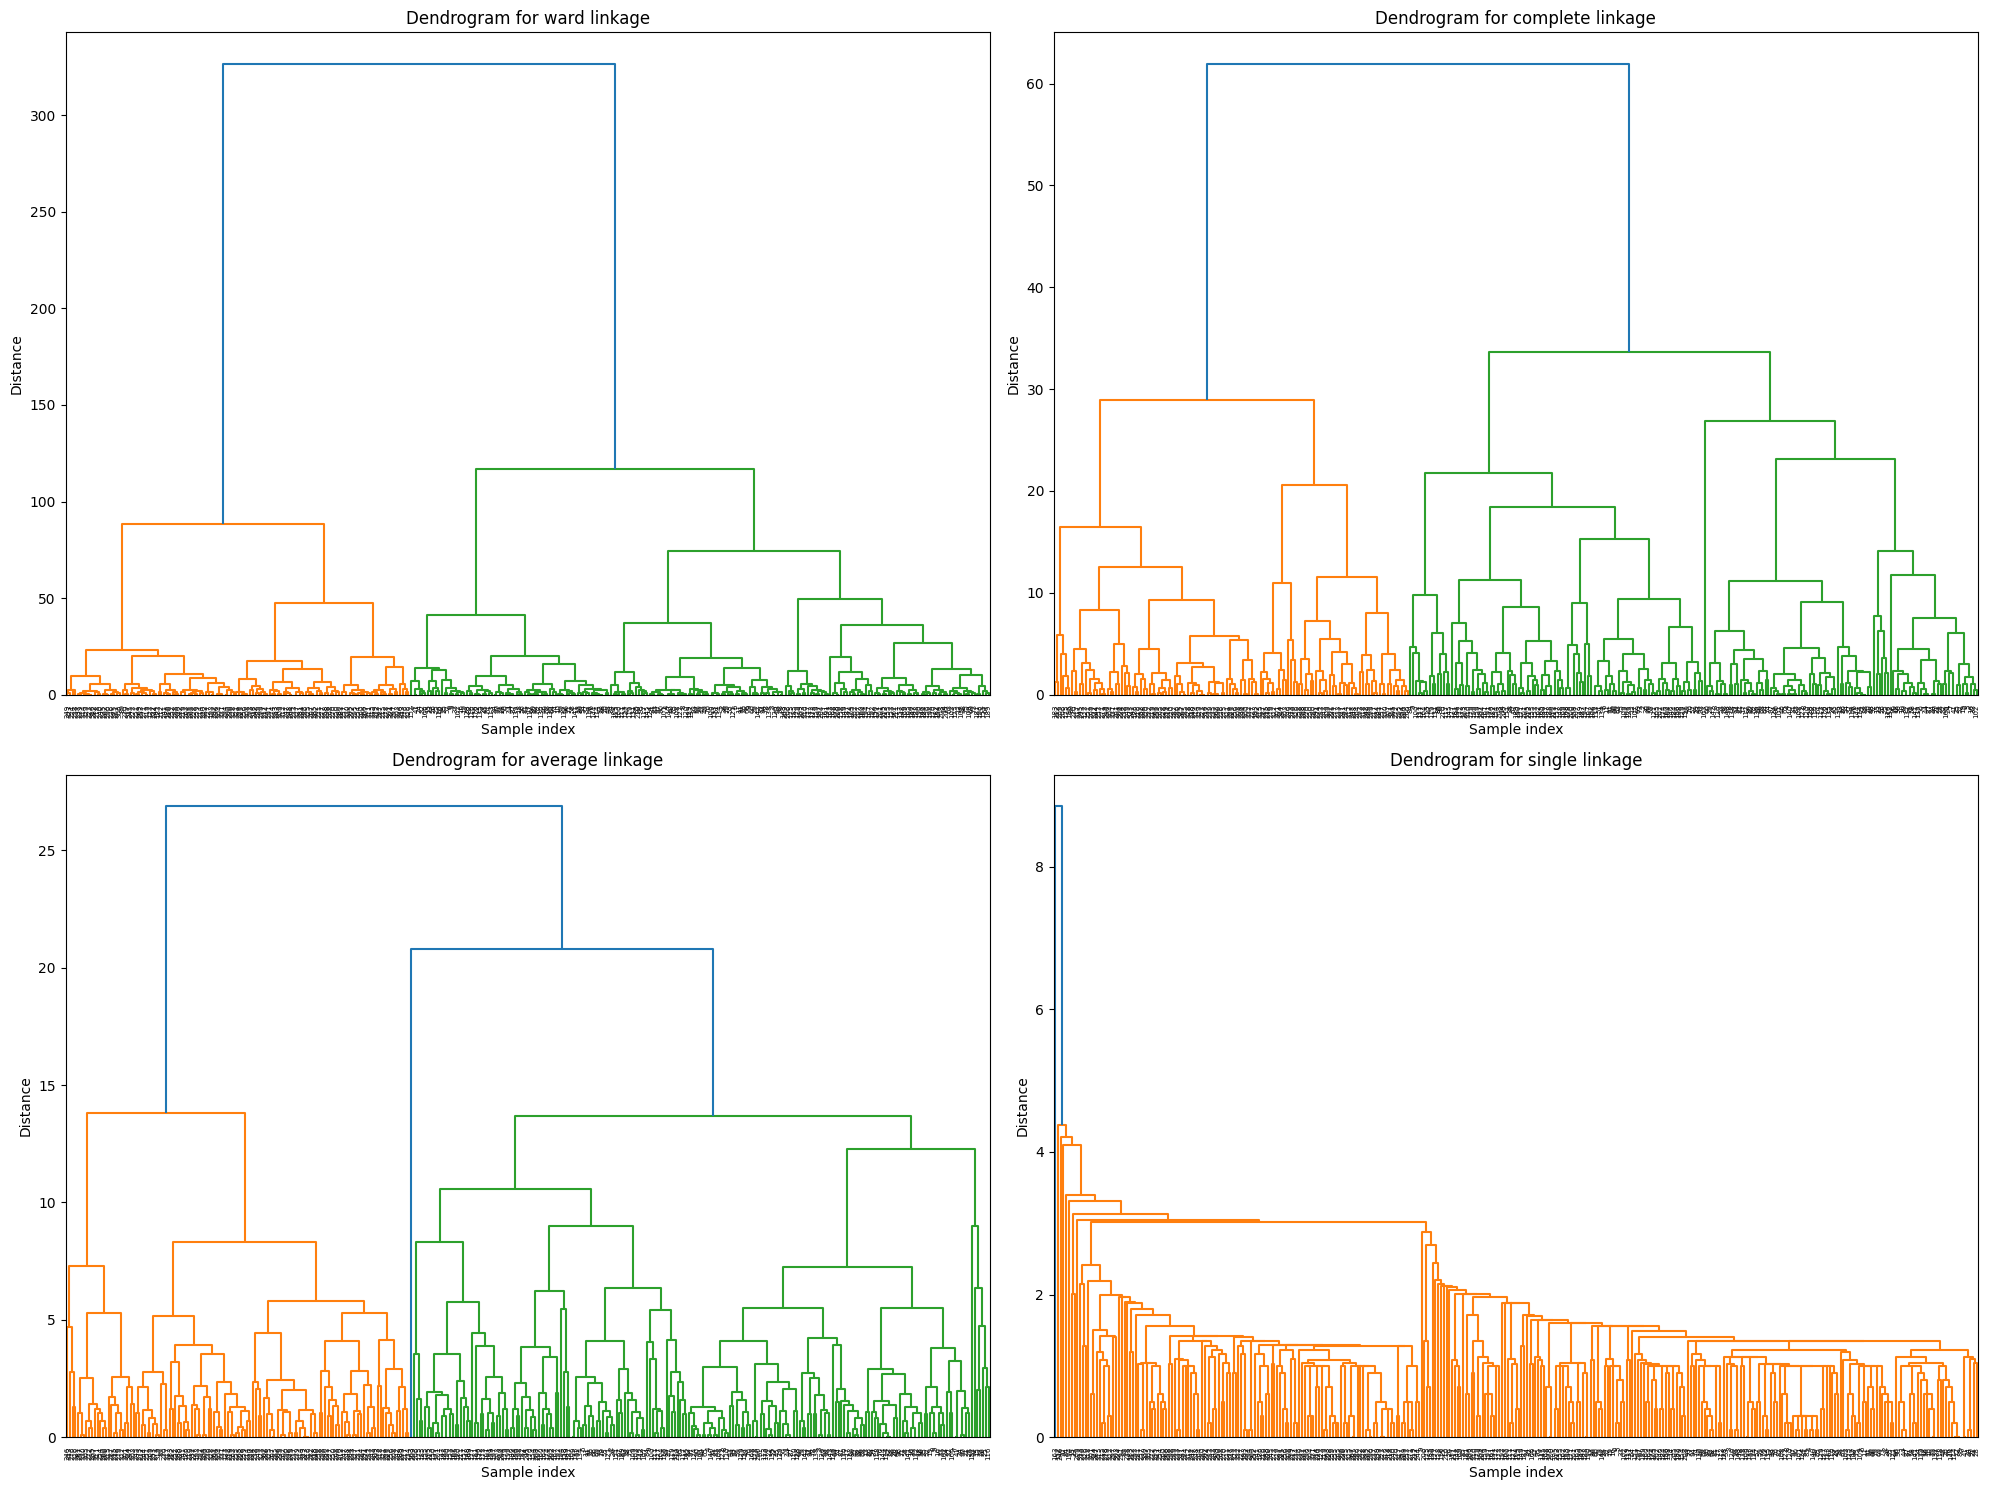

In [18]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

linkage_methods = ['ward', 'complete', 'average', 'single']

plt.figure(figsize=(20, 15))
for i, method in enumerate(linkage_methods):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid for plots
    Z = linkage(penguins_clustering_data, method=method)
    dendrogram(Z)
    plt.title(f'Dendrogram for {method} linkage')
    plt.xlabel('Sample index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

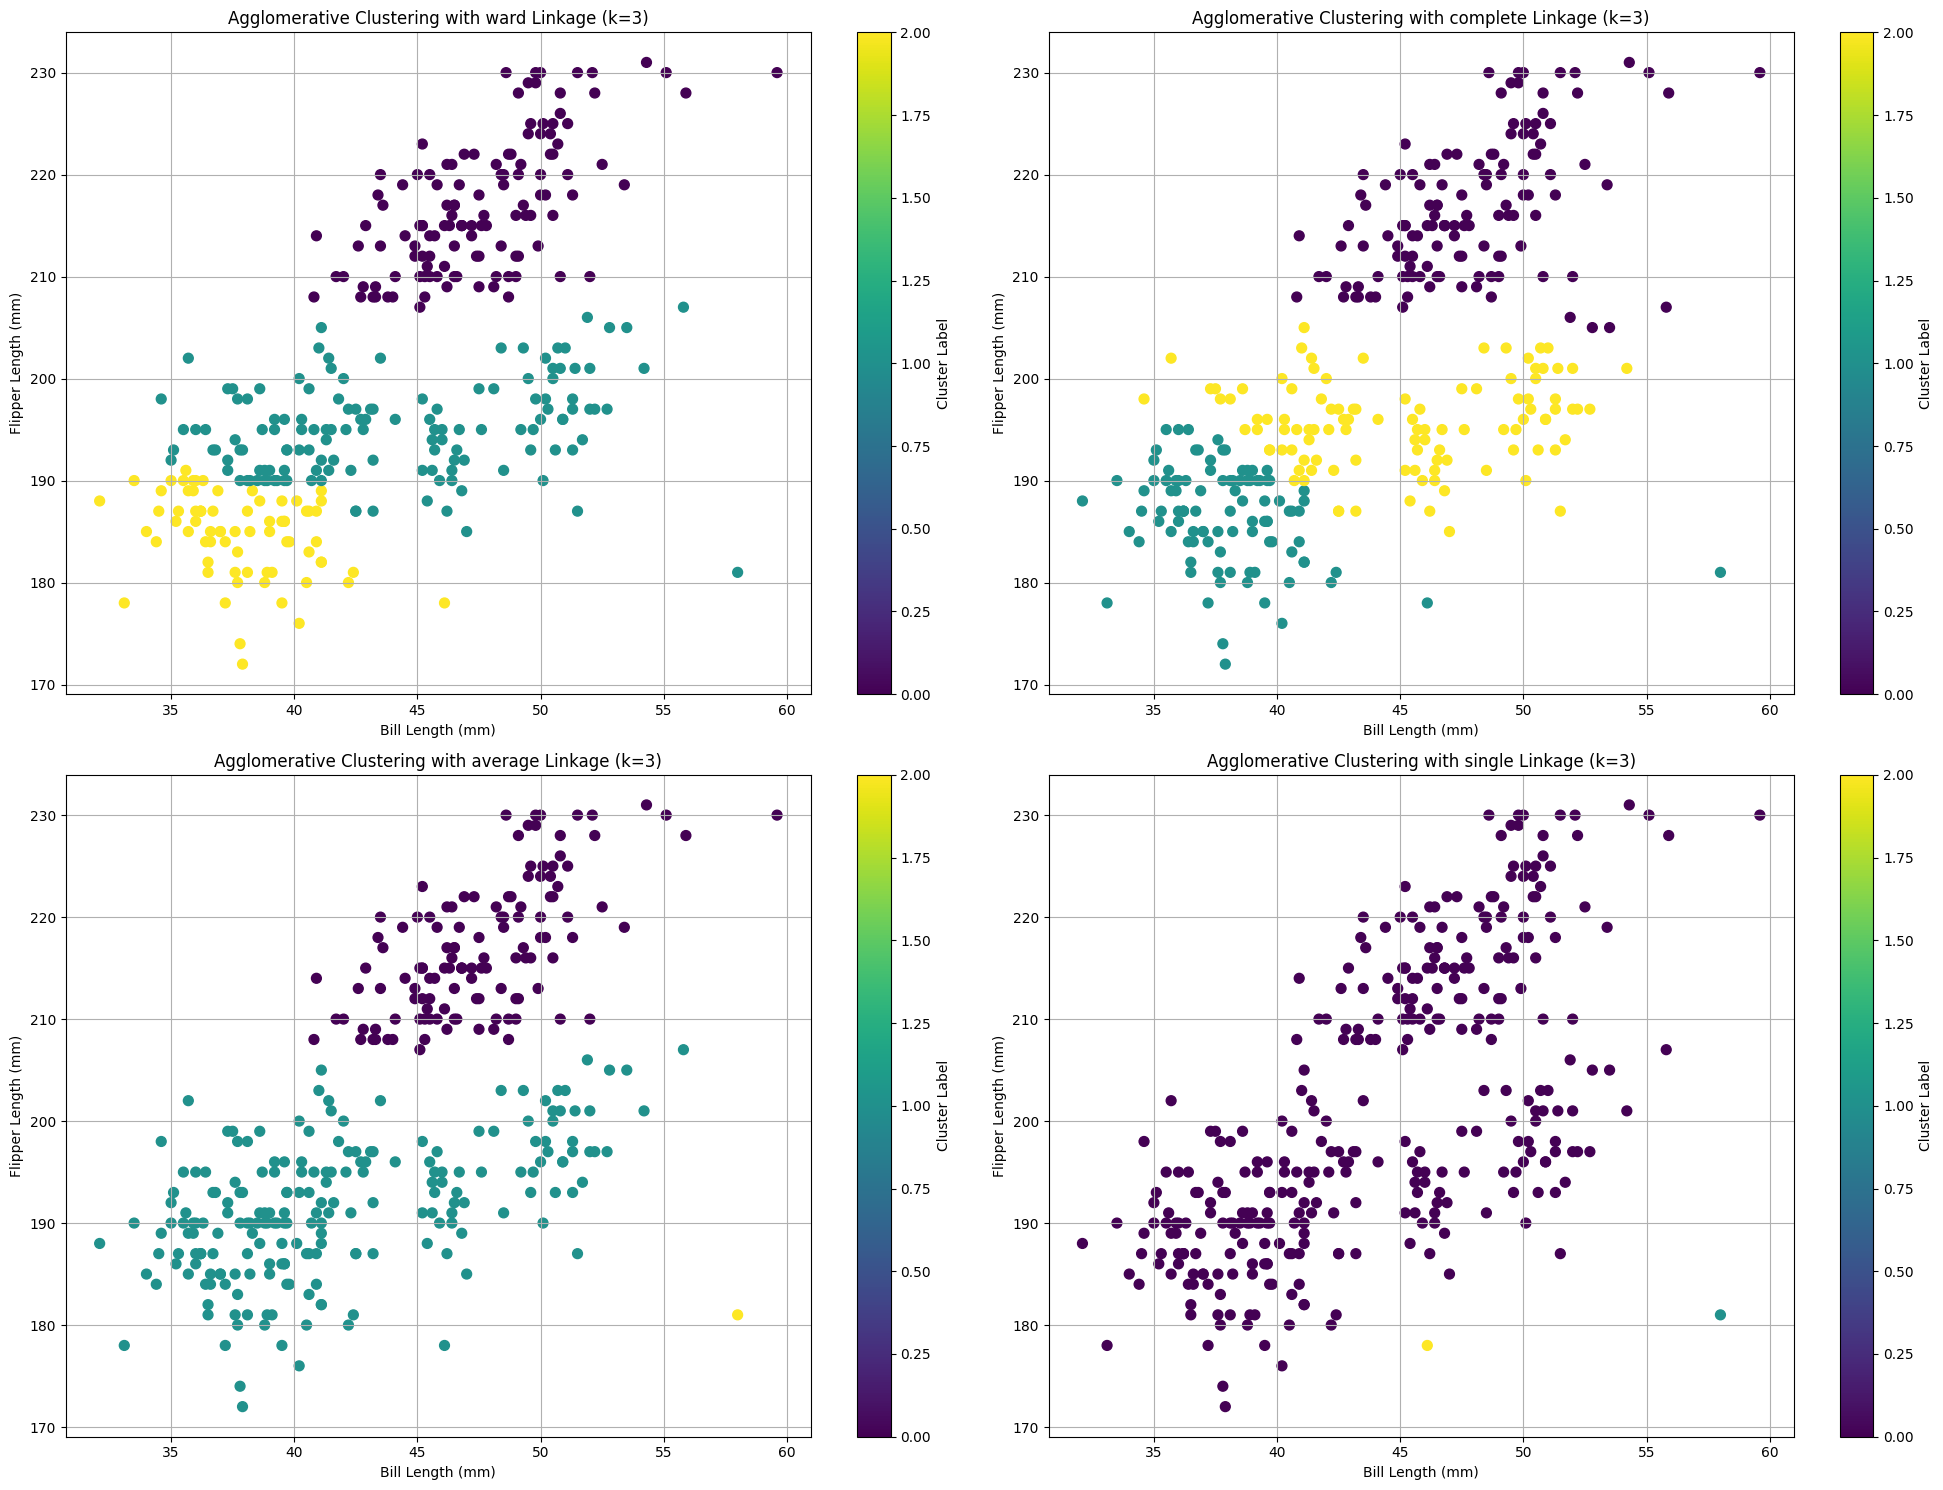

In [19]:
from sklearn.cluster import AgglomerativeClustering
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 15))
for i, method in enumerate(linkage_methods):
    cluster = AgglomerativeClustering(n_clusters=3, linkage=method, metric='euclidean')
    cluster_labels = cluster.fit_predict(penguins_clustering_data)

    plt.subplot(2, 2, i + 1)
    scatter = plt.scatter(penguins_clustering_data['bill_length_mm'],
                          penguins_clustering_data['flipper_length_mm'],
                          c=cluster_labels, cmap='viridis', s=50)
    plt.title(f'Agglomerative Clustering with {method} Linkage (k=3)')
    plt.xlabel('Bill Length (mm)')
    plt.ylabel('Flipper Length (mm)')
    plt.colorbar(scatter, label='Cluster Label')
    plt.grid(True)

plt.tight_layout()
plt.show()